## Group Comparisons

1. Participation Coefficient

2. Intra/Inter network segregation (connectivity?)


(same analysis for DNumRIsk data under `common_connectivity_stuff`)

In [3]:
import nibabel as nib
import numpy as np
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numberline'
ses = 1

subList = [int(sub[4:]) for sub in os.listdir(bids_folder) if sub.startswith('sub-')]
subArray = np.array(subList)
group_mapping = [1 if sub < 300 else 0 for sub in subList]  # Group 0: sub-001 to sub-099, Group 1: sub-100 onwards
group_mapping = pd.DataFrame({'subject': subList, 'group': group_mapping}).set_index('subject')

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
#mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

ci = glasser_CAatlas_mapping['ca_network'].values # community affiliation vector

In [4]:
print(*subList)

115 123 124 126 127 128 129 131 133 135 136 137 138 139 140 304 308 309 312 313 314 316 317 318 319 320 321 322 323 326 327


In [5]:
CMs = []
subArray = []
for sub in subList:
    try:
        cm = np.load(os.path.join(bids_folder, 'derivatives', 'correlation_matrices.parcel', f'sub-{sub}_ses-{ses}_confspec-36P.npy'))  # generated with getCM_parcel.py
        CMs.append(cm)
        subArray.append(sub)
    except FileNotFoundError:
        print(f"File not found for subject {sub}, session {ses}")
subArray = np.array(subArray)

File not found for subject 123, session 1
File not found for subject 127, session 1
File not found for subject 129, session 1
File not found for subject 138, session 1
File not found for subject 320, session 1
File not found for subject 327, session 1


### Participation Coefficient

In [16]:
from utils import participation_coef, threshold_matrix

df_PCs = []
df_meanNet_PCs = []
net_names = CAatlas_names['Network Name'].values

for cm in CMs:
    cm = threshold_matrix(cm, proportion=0.5)  # Threshold the matrix to keep only the top 15% of connections
    part_coefs = participation_coef(cm, ci)
    sub_meanNet_PCs = []
    for i_net in CAatlas_names.index.values:
        mask = (ci == i_net)
        sub_meanNet_PCs.append(part_coefs[mask].mean())
    df_meanNet_PCs.append(sub_meanNet_PCs)
    df_PCs.append(part_coefs) 

df_PCs = pd.DataFrame(df_PCs, index=subArray, columns=[f'parcel_{i}' for i in range(len(ci))])   
df_meanNet_PCs = pd.DataFrame(df_meanNet_PCs, index=subArray, columns=net_names)
df_meanNet_PCs.index.name = 'subject'

df_meanNet_PCs = df_meanNet_PCs.join(group_mapping)

/home/ubuntu/git/parietal_patterns/numberline_data/utils.py:42: RuntimeWarning: invalid value encountered in divide
  P = np.ones((n,)) - Kc2 / np.square(Ko) # divide


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.05, 'Participation Coefficient by Network - Group Comparisons')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


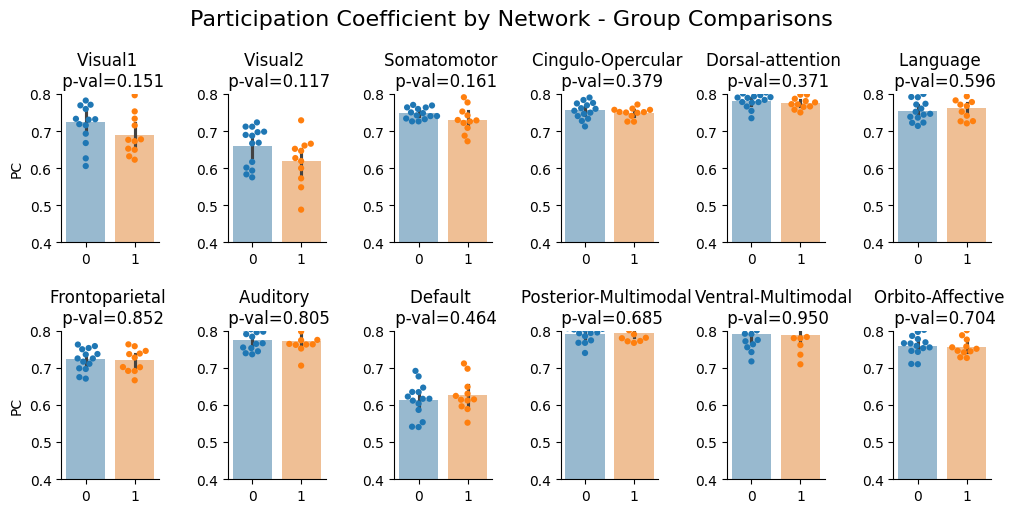

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

fig, axs = plt.subplots(2,6, figsize=(12,5))
axs = axs.flatten()

tmp = df_meanNet_PCs.set_index('group',append=True)

for i, net in enumerate(net_names):
        y_var = net
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False,ax=axs[i])
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=4.5,legend=False,ax=axs[i])
        stats = ttest_ind(tmp.xs(0,0,'group')[net], tmp.xs(1,0,'group')[net], axis=0, equal_var=False)
        axs[i].set(title=f'{y_var} \n p-val={stats.pvalue:.3f}', xlabel=None,ylim=(.4,.8))
        axs[i].set(ylabel='PC') if i == 0 or i == 6 else axs[i].set(ylabel=None)
        sns.despine()
#axs[1].set(ylim=(.2,.6)) # visual2 is different
#axs[8].set(ylim=(.2,.6)) # DMN is different

fig.subplots_adjust(hspace=0.6, wspace=0.7)
fig.suptitle('Participation Coefficient by Network - Group Comparisons', fontsize=16, y= 1.05)

--> Visual2-PC smaller for DD = aligns with gradient findings from DNumRisk?

## Intra/Inter network connectivity?

In [6]:
from scipy.stats import ttest_ind

CMs_array = np.transpose(np.array(CMs), (1, 2, 0)) 

N_nets = 12

mat_tstat = np.zeros([N_nets, N_nets])
mat_pvals = np.ones([N_nets, N_nets])
average_mean_BN_fc_strength = np.zeros([N_nets, N_nets])
for seed_net in range(1,N_nets+1):
    for target_net in range(seed_net, N_nets+1):
        network_seed_indices = np.where(glasser_CAatlas_mapping['ca_network'] == seed_net)[0]
        network_target_indices = np.where(glasser_CAatlas_mapping['ca_network'] == target_net)[0]
        
        mean_BN_fc_strength = CMs_array[np.ix_(network_seed_indices, network_target_indices)].mean(axis=(0,1))

        average_mean_BN_fc_strength[seed_net-1, target_net-1] = mean_BN_fc_strength.mean()

        df_mBNfc = pd.DataFrame(mean_BN_fc_strength, index=subArray, columns=['mean_BN_fc_strength'])   
        df_mBNfc.index.name = 'subject'
        df_mBNfc = df_mBNfc.join(group_mapping, on='subject')

        stats = ttest_ind(df_mBNfc[df_mBNfc['group'] == 0]['mean_BN_fc_strength'], df_mBNfc[df_mBNfc['group'] == 1]['mean_BN_fc_strength'], axis=0, equal_var=False)
        mat_tstat[seed_net-1, target_net-1] = stats.statistic
        mat_pvals[seed_net-1, target_net-1] = stats.pvalue
        

Text(0.5, 1.0, 'Inter/Intra-Network FC \n T-stats (blue larger in DD)')

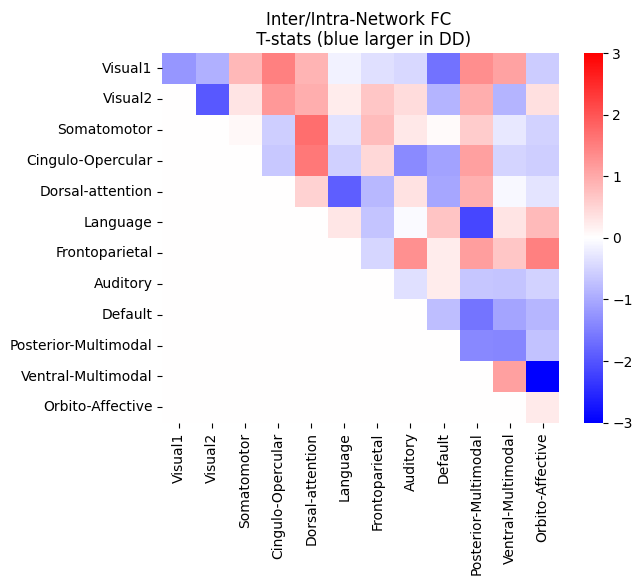

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(mat_tstat, cmap='bwr',vmin=-3,vmax=3,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Inter/Intra-Network FC \n T-stats (blue larger in DD)' )

Text(0.5, 1.0, 'Inter/Intra-Network FC \n P-vals')

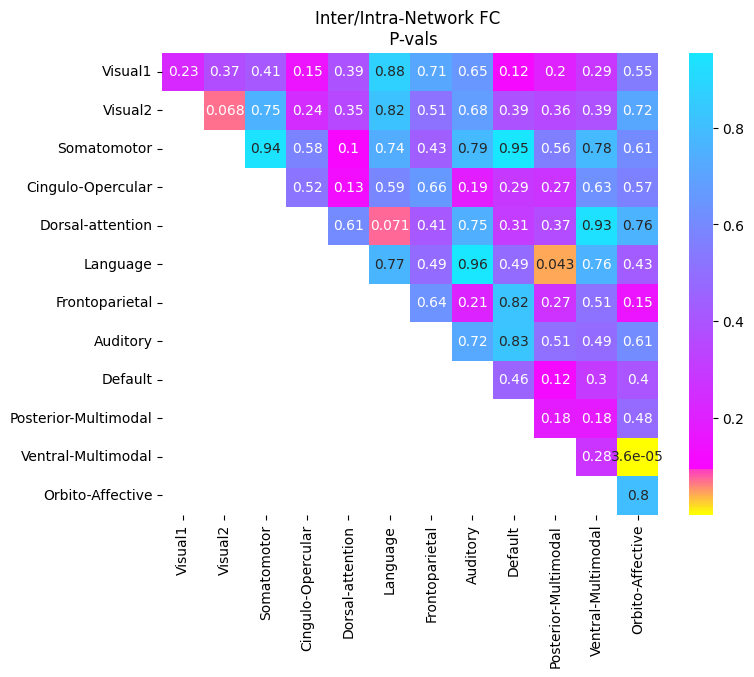

In [32]:
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap

pval_cmap = get_pval_colormap()

mat_pvals_ = mat_pvals.copy()
mat_pvals_[np.tril_indices_from(mat_pvals_, k=-1)] = np.nan

fig, axes = plt.subplots(1,1, figsize=(8,6)) 
sns.heatmap(mat_pvals_, cmap=pval_cmap,annot=True,ax=axes,#vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Inter/Intra-Network FC \n P-vals' , y=1.0)

In [10]:
np.ix_(network_seed_indices, network_target_indices)

(array([[  0],
        [120],
        [141],
        [180],
        [300],
        [321]]),
 array([[  0, 120, 141, 180, 300, 321]]))

In [12]:
CMs_array = np.transpose(CMs_array, (1, 2, 0))

In [20]:
CMs_array[np.ix_(network_seed_indices, network_target_indices),:].shape

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
 CMs_array[np.ix_(network_seed_indices, network_target_indices)